IPs: dict_keys(['axi_gpio_0', 'i2s_receiver_0', 'i2s_transmitter_0'])
Captured reads: 41177
Unique preambles: [1, 2, 3]
First 20 raw words:
0x07A12002
0x07A12002
0x07A12002
0x07A12002
0x07A12002
0x07A12002
0x07A12002
0x07A12002
0x07A12002
0x085EE002
0x085EE002
0x085EE002
0x085EE002
0x085EE002
0x085EE002
0x085EE002
0x085EE002
0x085EE002
0x085EE002
0x085EE002
Sample min: -8000000
Sample max: 8000000


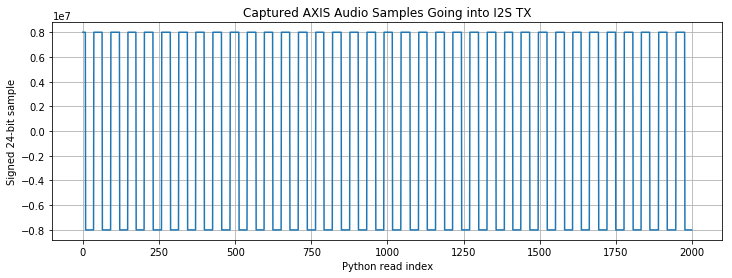

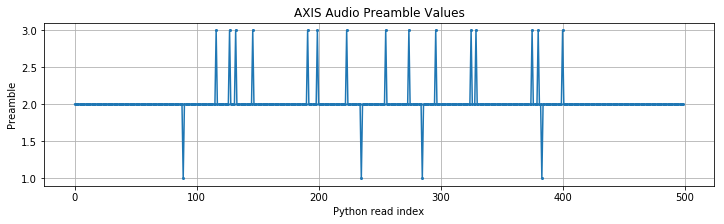

In [3]:
#Test with a slow square wave
from pynq import Overlay
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display


BITFILE = "audioTestk.bit"

ol = Overlay(BITFILE)
print("IPs:", ol.ip_dict.keys())

tx = ol.i2s_transmitter_0
dbg = ol.axi_gpio_0


def configure_tx():
    # Working TX setup
    tx.mmio.write(0x08, 0)
    time.sleep(0.2)

    tx.mmio.write(0x10, 0)
    tx.mmio.write(0x14, 0xFFFFFFFF)

    # Critical value from your sweep
    tx.mmio.write(0x20, 1)

    # Do not overwrite 0x30/0x34/0x38/0x3C
    # Optional validity
    tx.mmio.write(0x0C, 1)

    tx.mmio.write(0x14, 0xFFFFFFFF)
    time.sleep(0.1)

    tx.mmio.write(0x08, 1)
    time.sleep(0.5)


def unpack_axis_audio_word(raw):
    """
    Your AXIS word format:
      [31:28] control
      [27:4]  signed 24-bit sample
      [3:0]   preamble
    """
    preamble = raw & 0xF
    sample24 = (raw >> 4) & 0xFFFFFF

    # Sign extend 24-bit to Python int
    if sample24 & 0x800000:
        sample24 -= 1 << 24

    control = (raw >> 28) & 0xF

    return sample24, preamble, control


def capture_samples(duration=2.0):
    raw_values = []
    samples = []
    preambles = []
    controls = []

    start = time.time()

    while time.time() - start < duration:
        raw = int(dbg.channel1.read())
        sample, preamble, control = unpack_axis_audio_word(raw)

        raw_values.append(raw)
        samples.append(sample)
        preambles.append(preamble)
        controls.append(control)

    return (
        np.array(raw_values, dtype=np.uint32),
        np.array(samples, dtype=np.int32),
        np.array(preambles, dtype=np.int32),
        np.array(controls, dtype=np.int32),
    )


configure_tx()

raw, samples, preambles, controls = capture_samples(duration=2.0)

print("Captured reads:", len(samples))
print("Unique preambles:", sorted(set(preambles.tolist())))
print("First 20 raw words:")
for x in raw[:20]:
    print("0x{:08X}".format(int(x)))

print("Sample min:", samples.min())
print("Sample max:", samples.max())


# Plot raw sample values as seen by Python
plt.figure(figsize=(12, 4))
plt.plot(samples[:2000])
plt.title("Captured AXIS Audio Samples Going into I2S TX")
plt.xlabel("Python read index")
plt.ylabel("Signed 24-bit sample")
plt.grid(True)
plt.show()


# Plot preambles
plt.figure(figsize=(12, 3))
plt.plot(preambles[:500], marker="o", markersize=2)
plt.title("AXIS Audio Preamble Values")
plt.xlabel("Python read index")
plt.ylabel("Preamble")
plt.grid(True)
plt.show()

IPs: dict_keys(['axi_gpio_0', 'i2s_receiver_0', 'i2s_transmitter_0'])

Configuring RX + TX...
RX + TX enabled.

TX registers:
0x00: 0x00010000
0x04: 0x00010201
0x08: 0x00000001
0x0C: 0x00000001
0x10: 0x00000000
0x14: 0x00000001
0x20: 0x00000001
0x30: 0x00000001
0x34: 0x00000002
0x38: 0x00000003
0x3C: 0x00000004

RX registers:
0x00: 0x00010000
0x04: 0x00010201
0x08: 0x00000001
0x0C: 0x00000000
0x10: 0x00000000
0x14: 0x00000001
0x20: 0x00000001
0x30: 0x00000001
0x34: 0x00000002
0x38: 0x00000003
0x3C: 0x00000004

Capturing receiver AXIS words through GPIO...

Captured reads: 63507
Unique preambles: [1, 2, 3]
Unique controls: [0, 8]
Sample min: 250000
Sample max: 3944304
Unique sample count: 4

First 20 raw words:
0x03C2F703
0x03C2F703
0x03C2F703
0x803D0903
0x803D0903
0x803D0903
0x803D0903
0x803D0903
0x803D0903
0x803D0903
0x03C2F703
0x03C2F703
0x03C2F703
0x803D0903
0x803D0903
0x803D0903
0x03C2F703
0x03C2F703
0x03C2F703
0x03C2F703

First 20 samples:
[3944304 3944304 3944304  250000  250000 

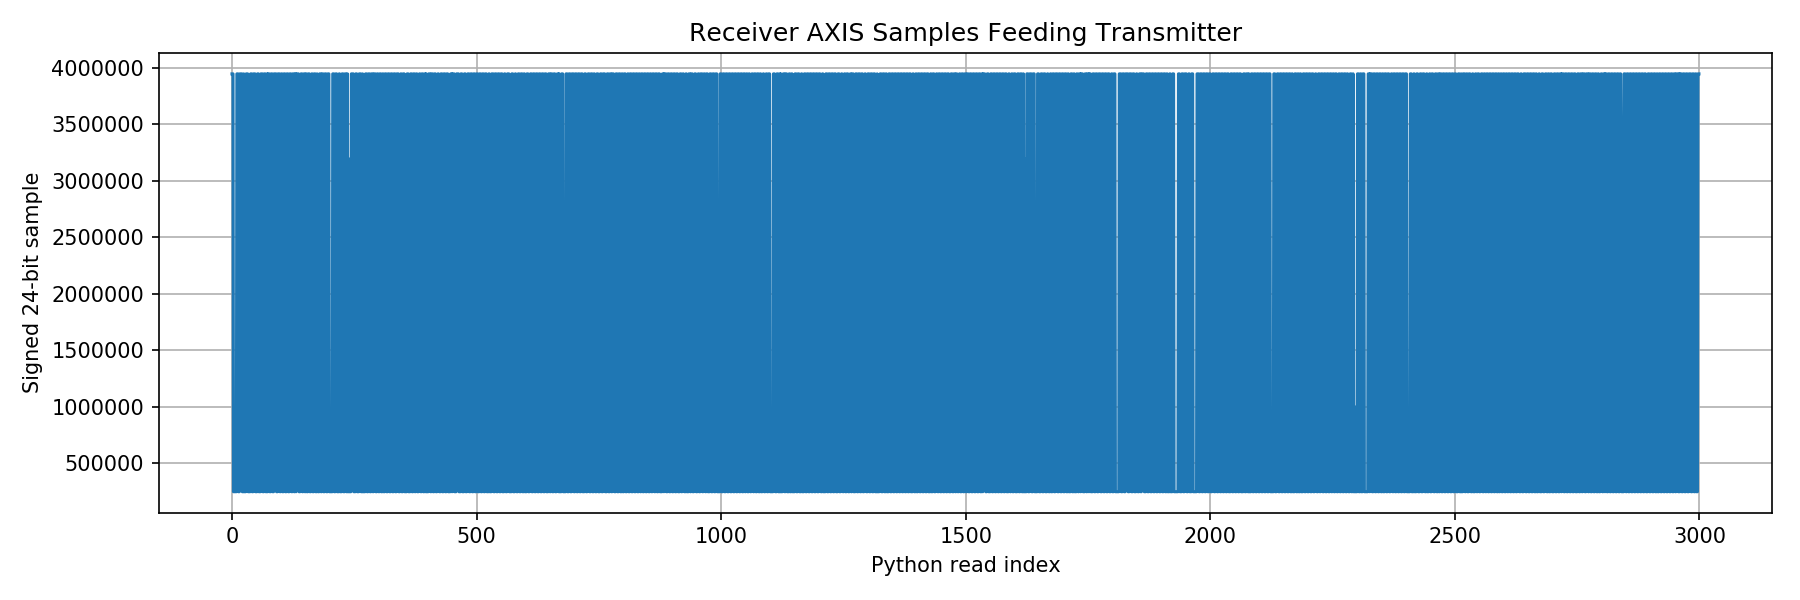

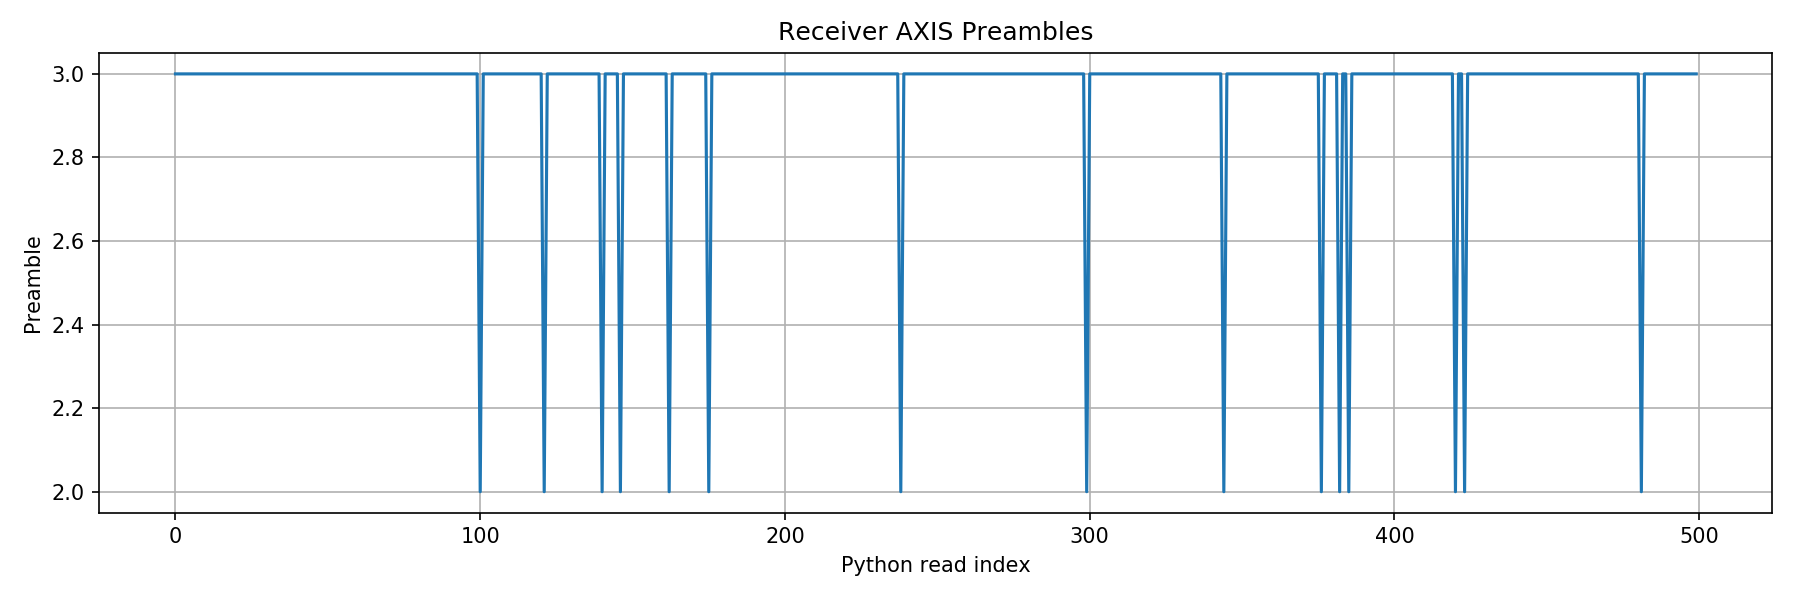


Capturing changed words only...
Changed words captured: 37993
Changed unique preambles: [1, 2, 3]
Changed sample min: 250000
Changed sample max: 3944304
Changed unique sample count: 4


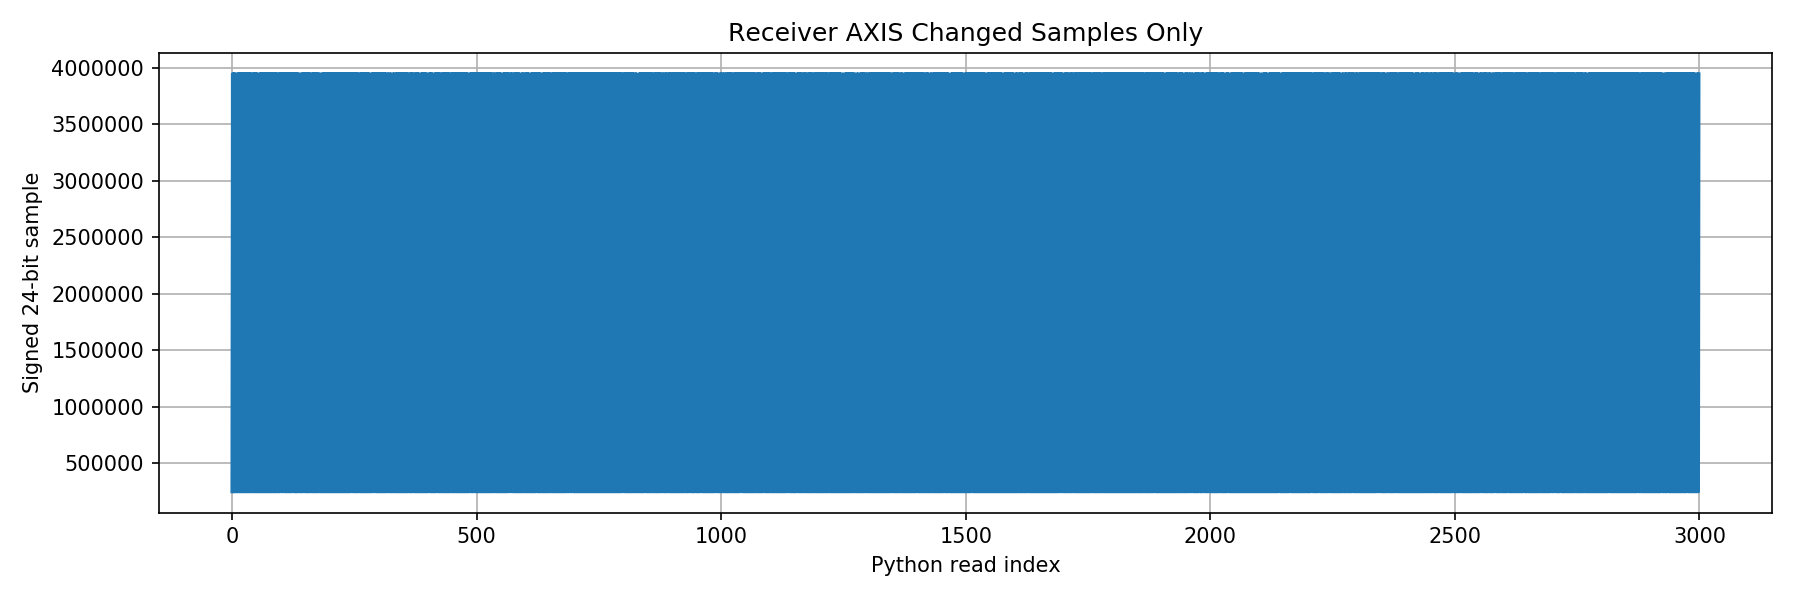


Test complete.
Expected:
1. RX registers and TX registers should both show 0x08 = 1.
2. Unique preambles should include 1, 2, and 3.
3. Samples should show your serial test pattern.
4. If TX is connected to the codec output path, this stream is also feeding the transmitter.


In [1]:
#Python test that runs a square wave with 4 different values, does not play audio but proves the I2S path is alive
from pynq import Overlay
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

BITFILE = "audioTestk.bit"   

ol = Overlay(BITFILE)
print("IPs:", ol.ip_dict.keys())

rx = ol.i2s_receiver_0
tx = ol.i2s_transmitter_0
dbg = ol.axi_gpio_0


# ------------------------------------------------------------
# Register helpers
# ------------------------------------------------------------

def dump_ip(ip, name):
    print("\n{} registers:".format(name))
    for off in [0x00, 0x04, 0x08, 0x0C, 0x10, 0x14, 0x20, 0x30, 0x34, 0x38, 0x3C]:
        try:
            print("0x{:02X}: 0x{:08X}".format(off, ip.mmio.read(off)))
        except Exception:
            pass


def configure_rx_tx():
    print("\nConfiguring RX + TX...")

    # Disable both
    rx.mmio.write(0x08, 0)
    tx.mmio.write(0x08, 0)
    time.sleep(0.2)

    # Disable interrupts
    rx.mmio.write(0x10, 0)
    tx.mmio.write(0x10, 0)

    # Clear status
    rx.mmio.write(0x14, 0xFFFFFFFF)
    tx.mmio.write(0x14, 0xFFFFFFFF)

    # Working timing divider from your previous tests
    rx.mmio.write(0x20, 1)
    tx.mmio.write(0x20, 1)

    # TX validity register. This worked before.
    tx.mmio.write(0x0C, 1)

    # IMPORTANT:
    # Do not overwrite TX channel mux registers:
    # 0x30, 0x34, 0x38, 0x3C
    # The defaults worked:
    # 0x30=1, 0x34=2, 0x38=3, 0x3C=4

    # Clear status again
    rx.mmio.write(0x14, 0xFFFFFFFF)
    tx.mmio.write(0x14, 0xFFFFFFFF)

    time.sleep(0.1)

    # Enable TX first so clocks/output side are alive
    tx.mmio.write(0x08, 1)
    time.sleep(0.2)

    # Enable RX
    rx.mmio.write(0x08, 1)
    time.sleep(0.5)

    print("RX + TX enabled.")


# ------------------------------------------------------------
# AXIS audio unpacking
# ------------------------------------------------------------

def unpack_axis_audio(raw):
    """
    AXIS audio word format:
      [31:28] = control bits
      [27:4]  = signed 24-bit sample
      [3:0]   = preamble
    """
    control = (raw >> 28) & 0xF
    sample24 = (raw >> 4) & 0xFFFFFF
    preamble = raw & 0xF

    # Sign extend 24-bit
    if sample24 & 0x800000:
        sample24 -= 1 << 24

    return sample24, preamble, control


def capture_debug_words(duration=3.0):
    raws = []
    samples = []
    preambles = []
    controls = []

    start = time.time()

    while time.time() - start < duration:
        raw = int(dbg.channel1.read())
        sample, preamble, control = unpack_axis_audio(raw)

        raws.append(raw)
        samples.append(sample)
        preambles.append(preamble)
        controls.append(control)

    return (
        np.array(raws, dtype=np.uint32),
        np.array(samples, dtype=np.int32),
        np.array(preambles, dtype=np.int32),
        np.array(controls, dtype=np.int32),
    )


def capture_changed_words(duration=3.0):
    raws = []
    samples = []
    preambles = []
    controls = []

    last_raw = None
    start = time.time()

    while time.time() - start < duration:
        raw = int(dbg.channel1.read())

        if raw != last_raw:
            sample, preamble, control = unpack_axis_audio(raw)

            raws.append(raw)
            samples.append(sample)
            preambles.append(preamble)
            controls.append(control)

            last_raw = raw

    return (
        np.array(raws, dtype=np.uint32),
        np.array(samples, dtype=np.int32),
        np.array(preambles, dtype=np.int32),
        np.array(controls, dtype=np.int32),
    )


def plot_array(values, title, ylabel, filename, limit=3000):
    plt.figure(figsize=(12, 4))
    plt.plot(values[:limit])
    plt.title(title)
    plt.xlabel("Python read index")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.close()
    display(Image(filename=filename))


# ------------------------------------------------------------
# Run test
# ------------------------------------------------------------

configure_rx_tx()

dump_ip(tx, "TX")
dump_ip(rx, "RX")

print("\nCapturing receiver AXIS words through GPIO...")
raws, samples, preambles, controls = capture_debug_words(duration=3.0)

print("\nCaptured reads:", len(samples))
print("Unique preambles:", sorted(set(preambles.tolist())))
print("Unique controls:", sorted(set(controls.tolist())))
print("Sample min:", samples.min())
print("Sample max:", samples.max())
print("Unique sample count:", len(set(samples.tolist())))

print("\nFirst 20 raw words:")
for x in raws[:20]:
    print("0x{:08X}".format(int(x)))

print("\nFirst 20 samples:")
print(samples[:20])

plot_array(
    samples,
    "Receiver AXIS Samples Feeding Transmitter",
    "Signed 24-bit sample",
    "/home/xilinx/rx_tx_samples.png",
    limit=3000
)

plot_array(
    preambles,
    "Receiver AXIS Preambles",
    "Preamble",
    "/home/xilinx/rx_tx_preambles.png",
    limit=500
)

print("\nCapturing changed words only...")
raws2, samples2, preambles2, controls2 = capture_changed_words(duration=3.0)

print("Changed words captured:", len(samples2))
if len(samples2) > 0:
    print("Changed unique preambles:", sorted(set(preambles2.tolist())))
    print("Changed sample min:", samples2.min())
    print("Changed sample max:", samples2.max())
    print("Changed unique sample count:", len(set(samples2.tolist())))

    plot_array(
        samples2,
        "Receiver AXIS Changed Samples Only",
        "Signed 24-bit sample",
        "/home/xilinx/rx_tx_changed_samples.png",
        limit=3000
    )

print("\nTest complete.")
print("Expected:")
print("1. RX registers and TX registers should both show 0x08 = 1.")
print("2. Unique preambles should include 1, 2, and 3.")
print("3. Samples should show your serial test pattern.")
print("4. If TX is connected to the codec output path, this stream is also feeding the transmitter.")